# SECOM dataset ML Project
---

### Loading in the SECOM dataset

In [235]:
# Imports
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

In [236]:
# Pulling in the SECOM data and loading data into feature and label dataframes
secom = fetch_ucirepo(id=179)
df = pd.DataFrame(secom.data.original)
X = df.drop(columns=["class", "timestamp"])
y = df["class"]

print(X.shape)
print(y.shape)

(1567, 590)
(1567,)


---

### Exploratory Data Analysis (EDA)

In [237]:
# checking data types of features
X.dtypes.value_counts()

float64    590
Name: count, dtype: int64

In [238]:
# checking null counts and null percentage of features
feature_summary = pd.DataFrame({
    "null_counts": X.isna().sum(),
    "null_pct": round(X.isna().mean()*100, 2)
}).sort_values("null_pct", ascending=False)

print(feature_summary.head(50))

               null_counts  null_pct
Attribute 293         1429     91.19
Attribute 294         1429     91.19
Attribute 159         1429     91.19
Attribute 158         1429     91.19
Attribute 493         1341     85.58
Attribute 86          1341     85.58
Attribute 359         1341     85.58
Attribute 221         1341     85.58
Attribute 245         1018     64.96
Attribute 518         1018     64.96
Attribute 110         1018     64.96
Attribute 247         1018     64.96
Attribute 384         1018     64.96
Attribute 383         1018     64.96
Attribute 385         1018     64.96
Attribute 246         1018     64.96
Attribute 112         1018     64.96
Attribute 111         1018     64.96
Attribute 517         1018     64.96
Attribute 519         1018     64.96
Attribute 581          949     60.56
Attribute 579          949     60.56
Attribute 580          949     60.56
Attribute 582          949     60.56
Attribute 74           794     50.67
Attribute 346          794     50.67
A

In [239]:
# checking class balance and null counts
label_summary = pd.DataFrame({
    "counts": y.value_counts(),
    "null_counts": y.isna().sum(),
    "pct": round(y.value_counts()/len(y)*100, 2),    
})

print(label_summary)

       counts  null_counts    pct
class                            
-1       1463            0  93.36
 1        104            0   6.64


---

In [240]:
threshold = 90 # null pct threshold

null_cols = X.columns[X.isna().mean()*100 > threshold]
X_filtered = X.drop(columns=null_cols)
X_filtered.shape

(1567, 586)

In [241]:
# Fill remaining NaN values with median
X_filtered = X_filtered.fillna(X.median())
X_filtered.head()

,Attribute 1,Attribute 2,Attribute 3,Attribute 4,Attribute 5,Attribute 6,Attribute 7,Attribute 8,Attribute 9,Attribute 10,...,Attribute 581,Attribute 582,Attribute 583,Attribute 584,Attribute 585,Attribute 586,Attribute 587,Attribute 588,Attribute 589,Attribute 590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.0047,72.2889,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.0047,72.2889,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [242]:
# Remove constant variance terms
zero_var_cols = X_filtered.columns[X_filtered.var() == 0]
# X_filtered = pd.DataFrame(VarianceThreshold(threshold=0.0).fit_transform(X_filtered))
X_filtered = X_filtered.drop(columns=zero_var_cols)
X_filtered.shape

(1567, 470)

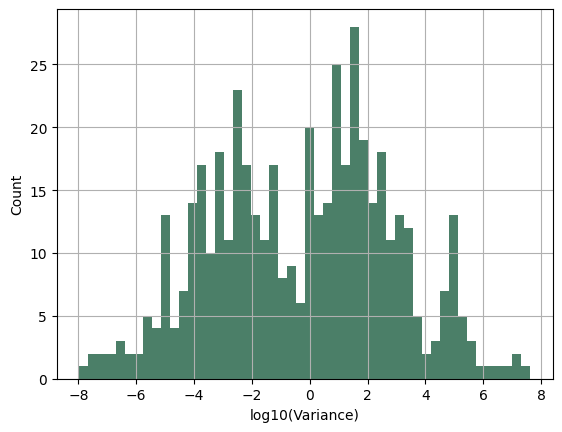

In [243]:
# Checking variance threshold to see if we have an obvious cutoff point
variances = X_filtered.var()

plt.hist(np.log10(variances), bins=50, color='#4B7F68')
plt.xlabel("log10(Variance)")
plt.ylabel("Count")
plt.grid()
plt.show()

In [256]:
corr = X_filtered.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "corr"]
pairs = pairs.sort_values(
    "corr",
    ascending=False
)

print(pairs.head(50))

            feature_1      feature_2      corr
32344    Attribute 75  Attribute 479  1.000000
133298  Attribute 343  Attribute 348  1.000000
89118   Attribute 210  Attribute 348  1.000000
89113   Attribute 210  Attribute 343  1.000000
89214   Attribute 210  Attribute 479  1.000000
32243    Attribute 75  Attribute 343  1.000000
32248    Attribute 75  Attribute 348  1.000000
32149    Attribute 75  Attribute 210  1.000000
135744  Attribute 348  Attribute 479  1.000000
87609   Attribute 207  Attribute 210  1.000000
87708   Attribute 207  Attribute 348  1.000000
87804   Attribute 207  Attribute 479  1.000000
32146    Attribute 75  Attribute 207  1.000000
87703   Attribute 207  Attribute 343  1.000000
133394  Attribute 343  Attribute 479  1.000000
15074    Attribute 35   Attribute 37  1.000000
62740   Attribute 141  Attribute 276  1.000000
75833   Attribute 173  Attribute 175  1.000000
121520  Attribute 308  Attribute 310  0.999999
67450   Attribute 153  Attribute 288  0.999997
99011   Attri

In [257]:
to_drop = [
    col
    for col in upper.columns
    if any(upper[col] > 0.95)
]

print(f"Columns to drop: {len(to_drop)}")

Columns to drop: 186


In [259]:
high_corr = pairs[pairs["corr"] > 0.95]
high_corr.sort_values("corr", ascending=False).head(100)

,feature_1,feature_2,corr
32344,Attribute 75,Attribute 479,1.000000
133298,Attribute 343,Attribute 348,1.000000
89118,Attribute 210,Attribute 348,1.000000
89113,Attribute 210,Attribute 343,1.000000
89214,Attribute 210,Attribute 479,1.000000
...,...,...,...
204417,Attribute 555,Attribute 558,0.995660
68964,Attribute 156,Attribute 429,0.995502
202062,Attribute 550,Attribute 553,0.995387
218545,Attribute 585,Attribute 586,0.995342
